In [14]:
from m_star_predictor import (
    LinearRegression, FCNN, fit_model
)

from utility import (
    normalize, real_units, reduce_dataset, compute_rmse, MStarPredictorConfig,
    get_predictions, get_mean_predictions, prepare_data, recover_M_from_dM
)

from epbl_basic import calculate_M

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
predictor_name = "predictor_24"
predictor_dir = os.path.join("m_star_predictors", predictor_name)
config_json_path = os.path.join(predictor_dir, "config.json")

with open(config_json_path, "r") as f:
    config_dict = json.load(f)

config = MStarPredictorConfig(**config_dict)

In [3]:
# Ensuring reproducibility
np.random.seed(config.random_state)
torch.manual_seed(config.random_state);
sklear_random_state = config.random_state

In [4]:
data_directory = '../m_star_dataset'

dataset_name = config.dataset_name
validation_dataset_name = config.validation_dataset_name

data = pd.read_csv(os.path.join(data_directory, f"{config.dataset_filename}.csv"))
validation_data = pd.read_csv(os.path.join(data_directory, f"{config.validation_dataset_filename}.csv"))

In [5]:
with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict = json.load(file)

In [6]:
X, y, X_val, y_val, fcnn_prediction, fcnn_prediction_val = get_predictions(
    training_data=data,
    validation_data=validation_data,
    config=config
)

In [7]:
config.rmse

2.857343517348454e-08

In [8]:
M_algebraic = calculate_M(
    H=validation_data["bl_tke"].values,
    f=validation_data["f"].values,
    u_star=validation_data["u_star"].values,
    B=validation_data["B"].values,
    neutral_mode="Nb",
    wb=-validation_data["wb"].values
)

In [9]:
mean_prediction, mean_prediction_val = get_mean_predictions(
    training_data=data,
    validation_data=validation_data,
    config=config
)

In [11]:
config.n_time_steps = 432
config.n_time_steps_val = 432

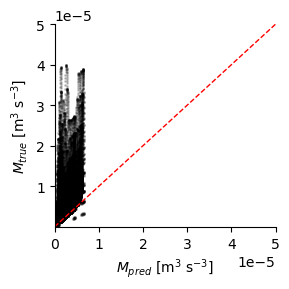

In [42]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(M_algebraic, y_val, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("algebraic_mtrue_mpred.png", dpi=300)

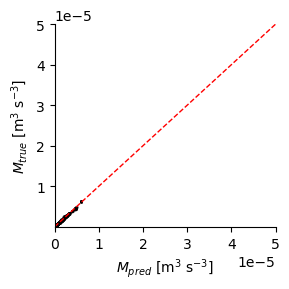

In [12]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(fcnn_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

# plt.savefig("interp_all_mtrue_mpred.png", dpi=300)

In [13]:
np.sqrt(np.mean((M_algebraic-y_val.detach().numpy())**2))

3.4280441139903626e-06

In [27]:
compute_rmse(mean_prediction_val, y_val)

tensor(2.9314e-06, grad_fn=<SqrtBackward0>)

In [32]:
y_val

tensor([[2.8778e-07],
        [6.1358e-07],
        [8.9951e-07],
        ...,
        [5.1810e-06],
        [5.1763e-06],
        [5.1710e-06]])

In [29]:
mean_prediction_val

tensor([[1.6470e-06],
        [1.4791e-06],
        [1.3227e-06],
        ...,
        [5.1116e-06],
        [5.1116e-06],
        [5.1116e-06]], grad_fn=<AddBackward0>)

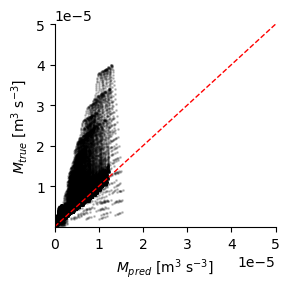

In [24]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(mean_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("mean_mtrue_mpred.png", dpi=300)

In [15]:
delta_pred = True

if delta_pred:
    prediction = recover_M_from_dM(
        dM=fcnn_prediction_val.detach().numpy(),
        n_time_steps=config.n_time_steps_val
    )
    truth = recover_M_from_dM(
        dM=y_val.detach().numpy(),
        n_time_steps=config.n_time_steps_val
    )
else:
    prediction = fcnn_prediction_val.detach().numpy()
    truth = y_val.detach().numpy()


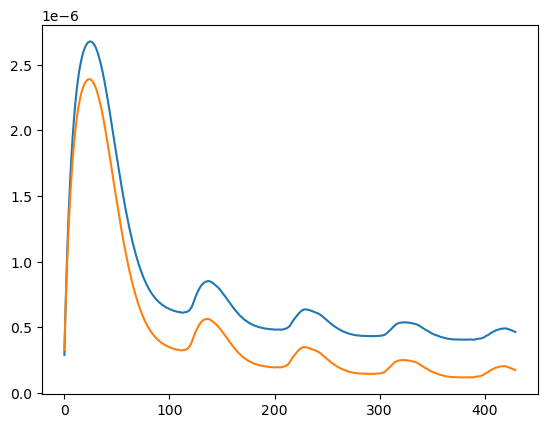

In [44]:
plt.plot(validation_data["M"][0:430])
plt.plot(truth[0:430])

/tmp/ipykernel_866605/4212059856.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1,1,figsize=(10,4),tight_layout=True,sharex=True)


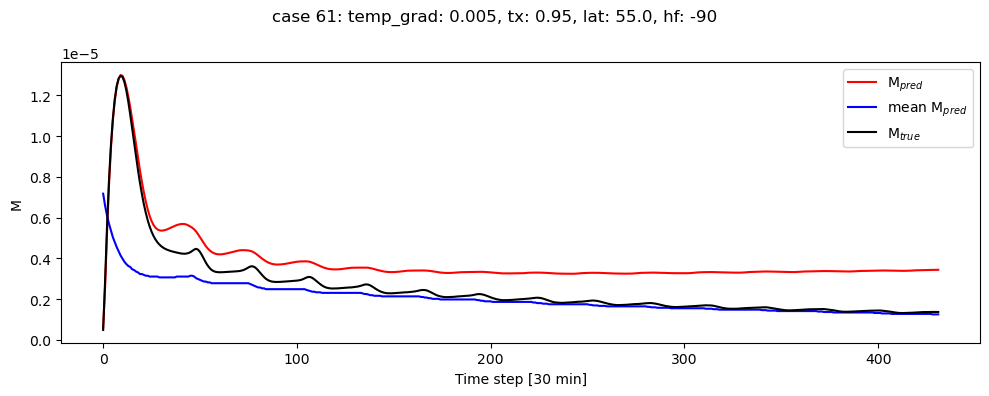

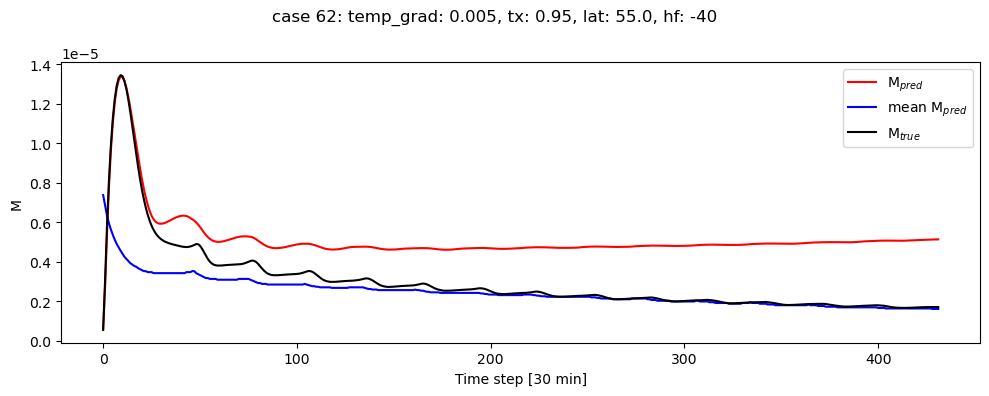

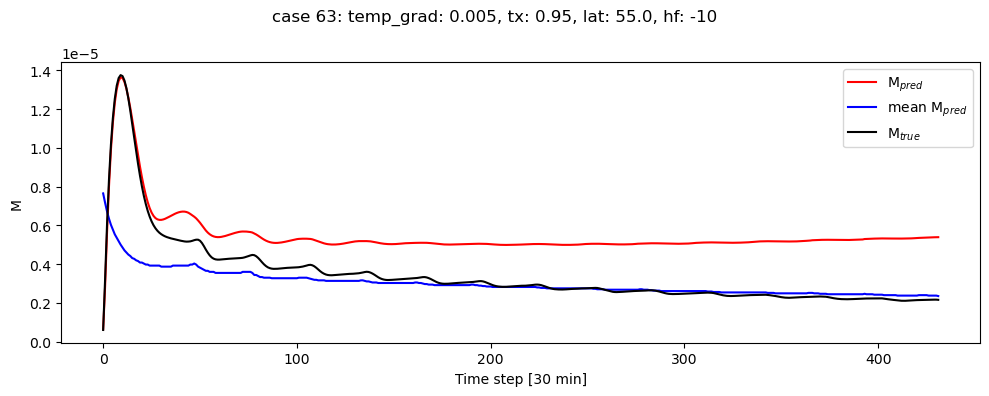

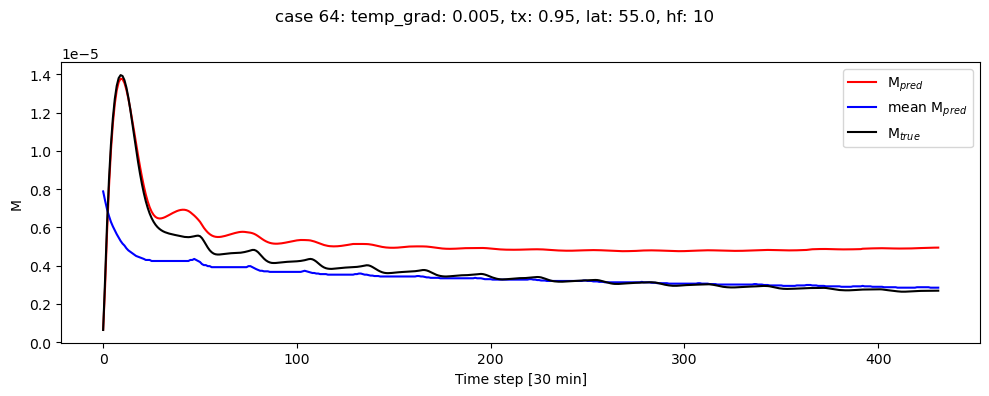

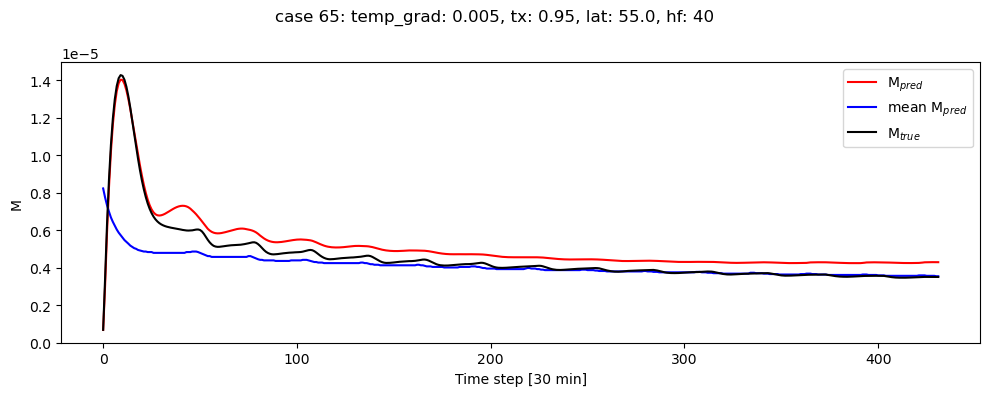

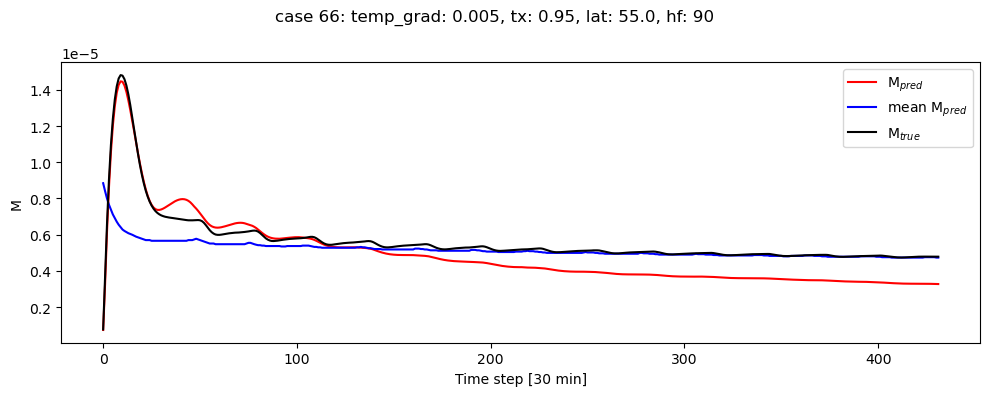

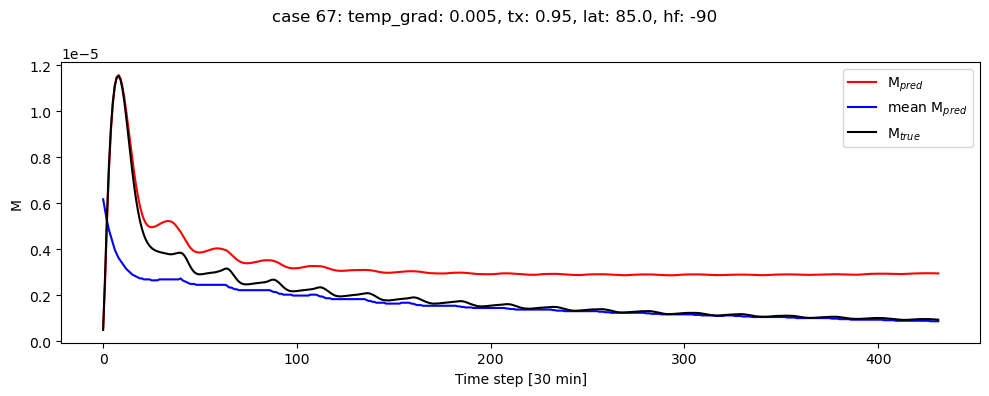

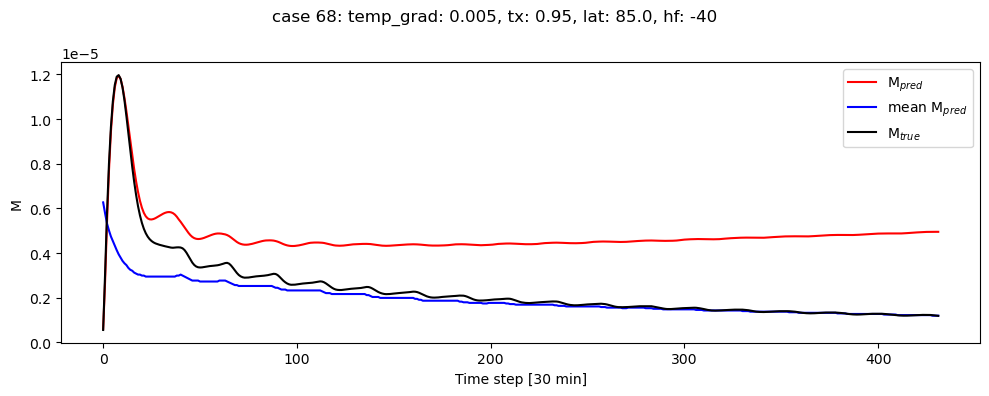

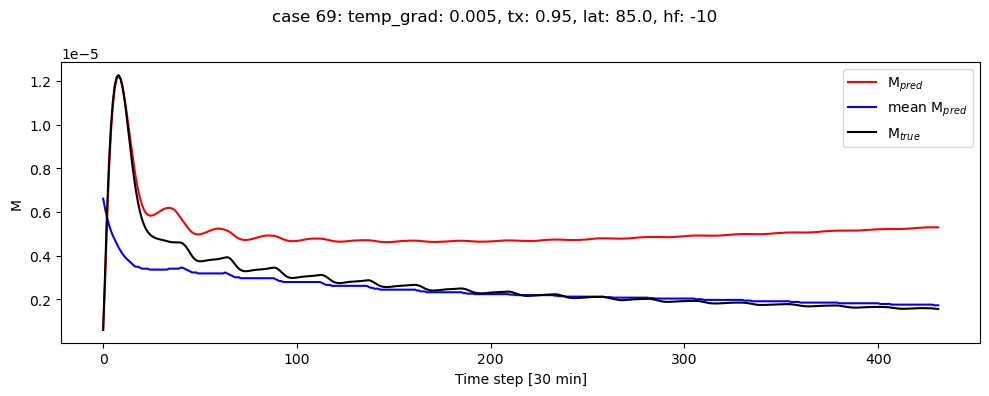

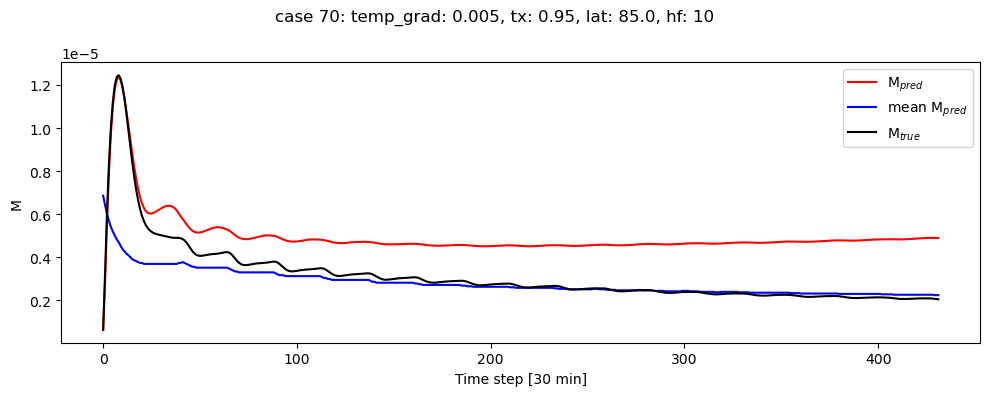

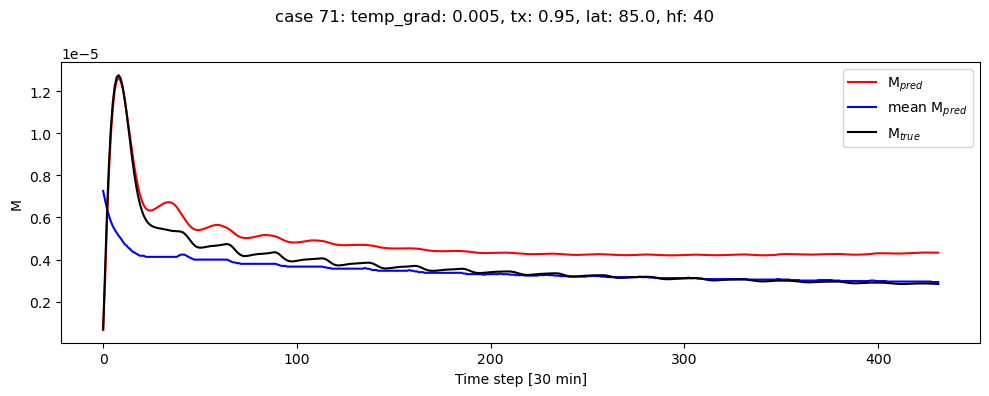

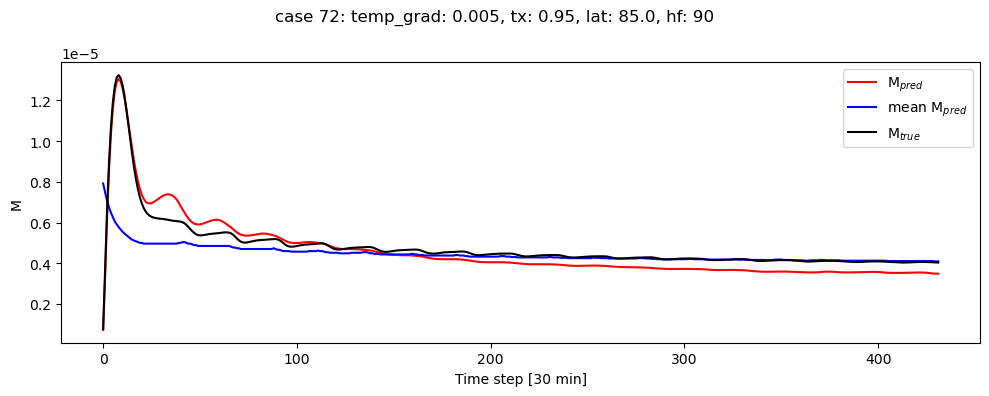

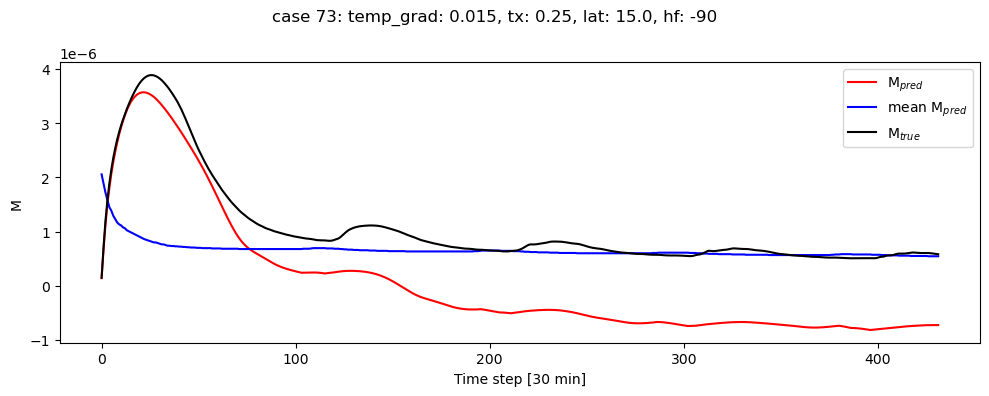

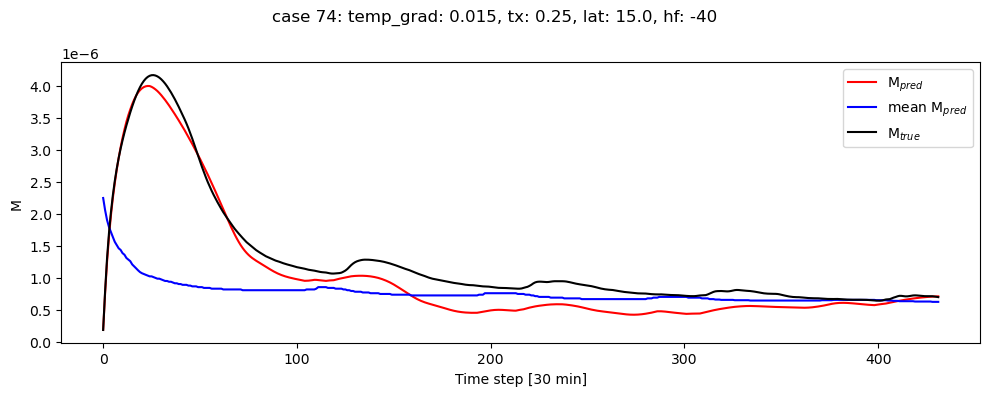

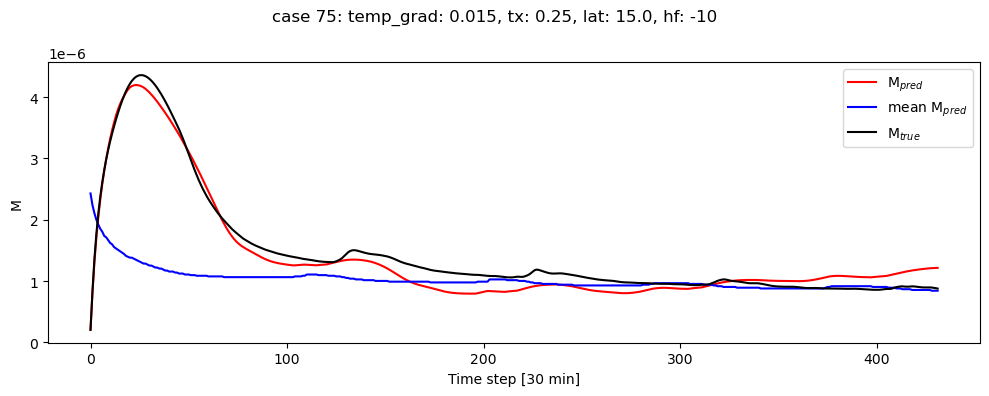

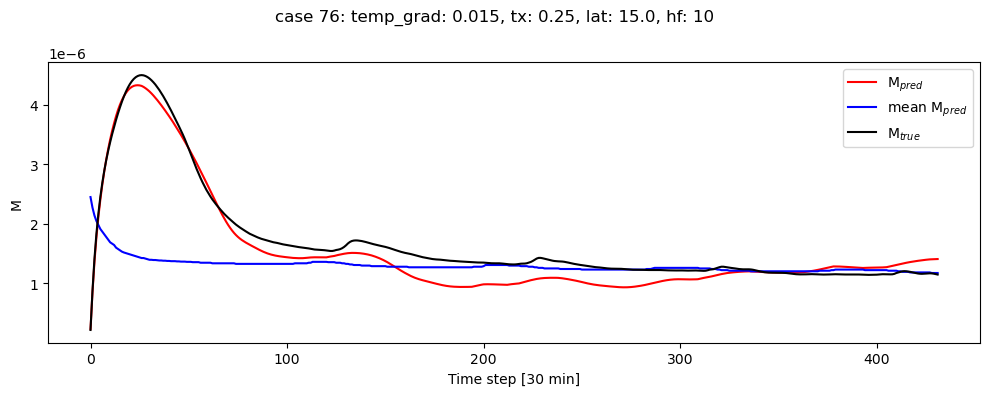

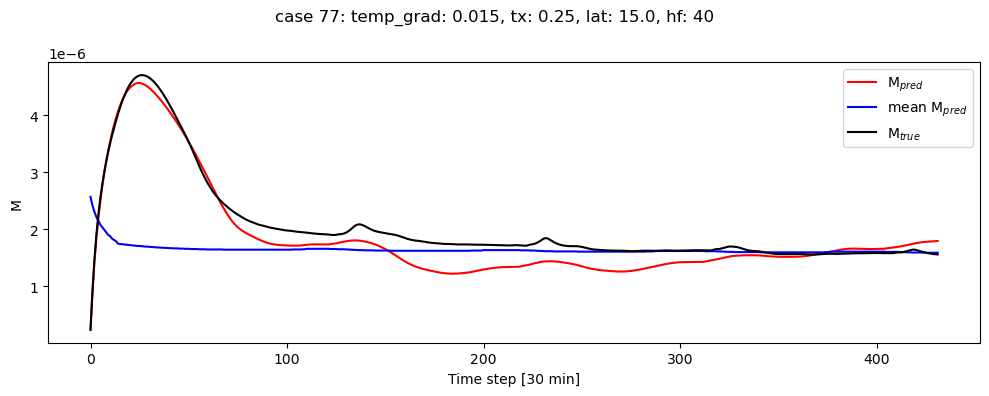

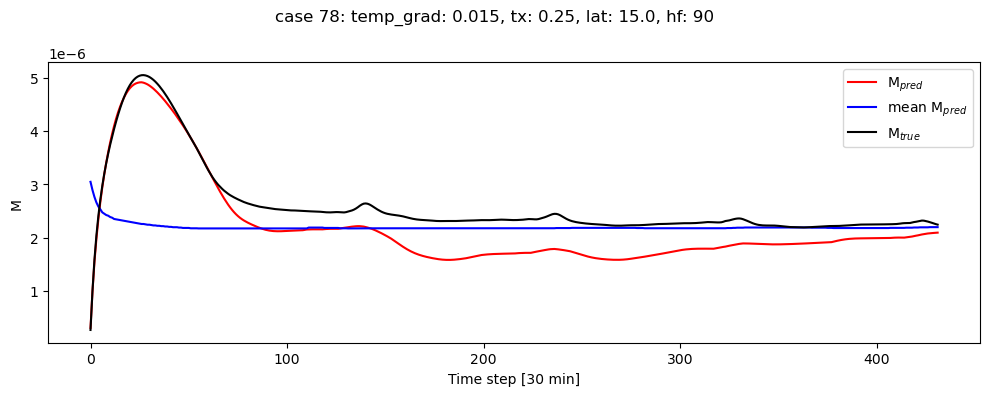

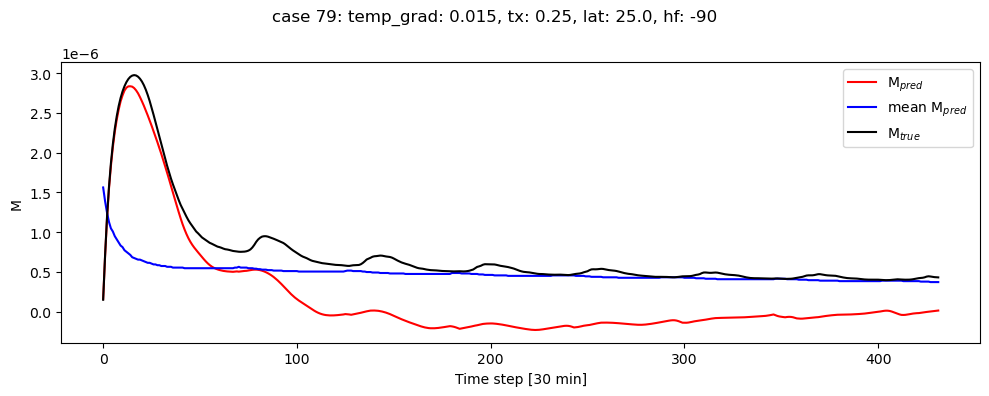

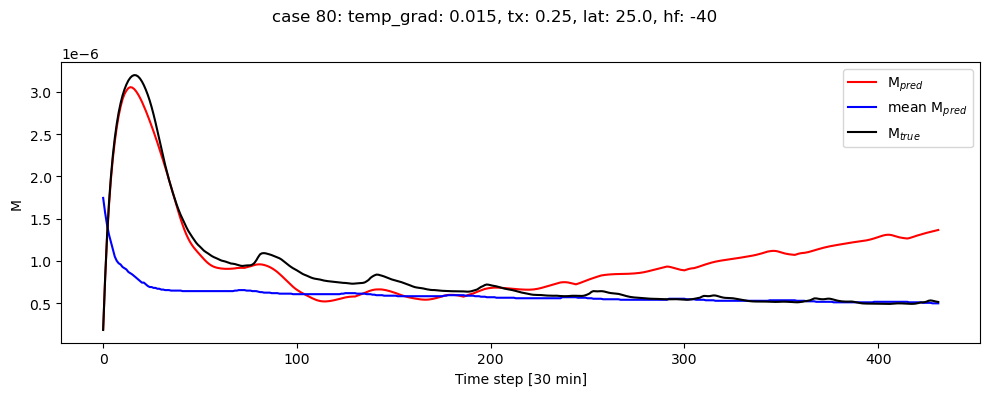

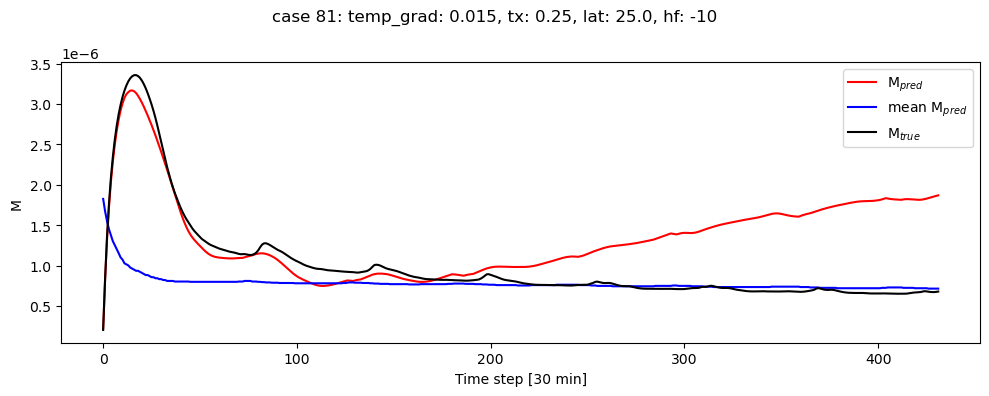

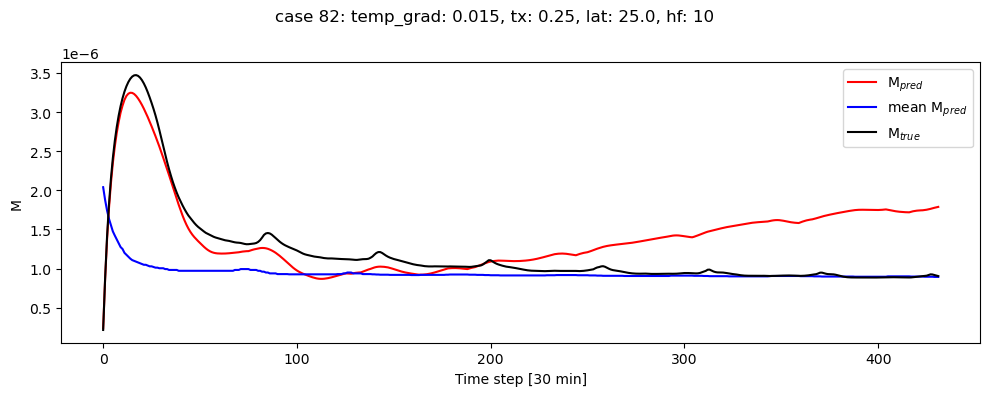

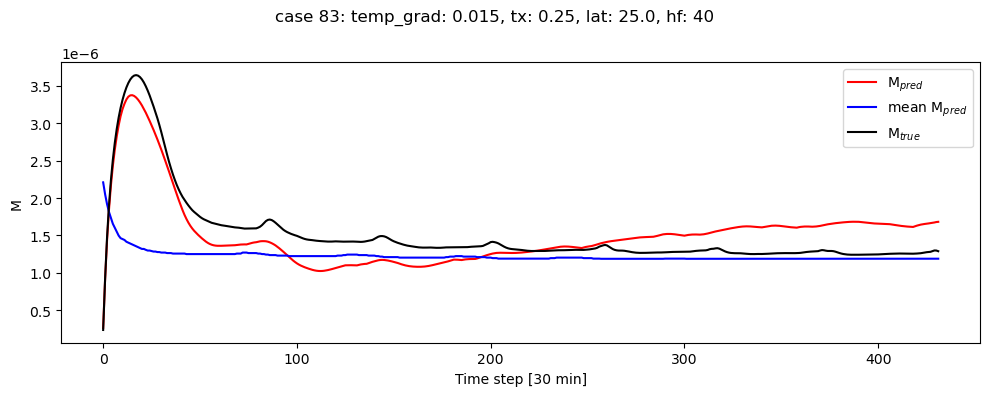

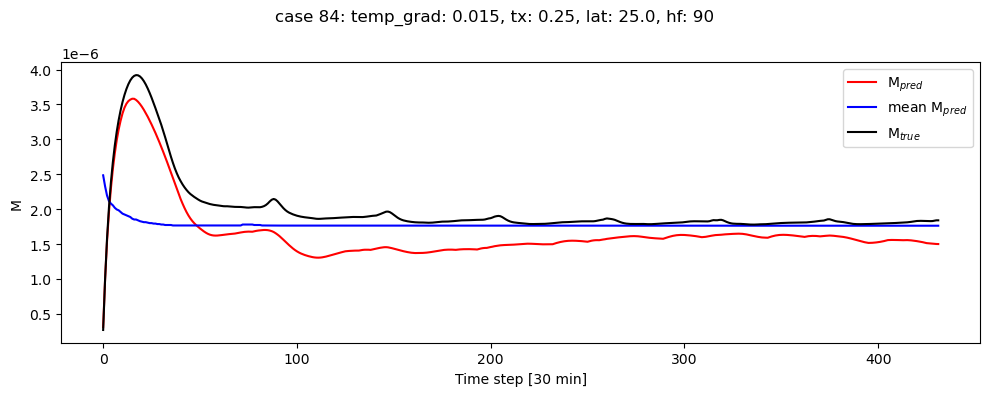

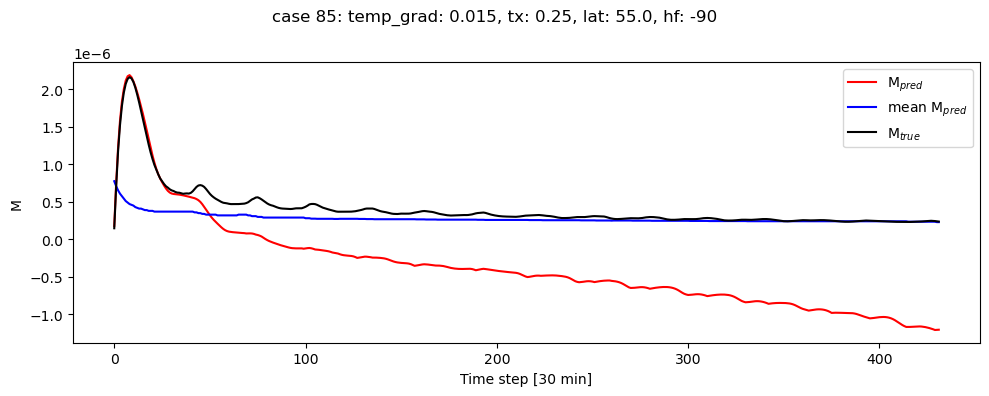

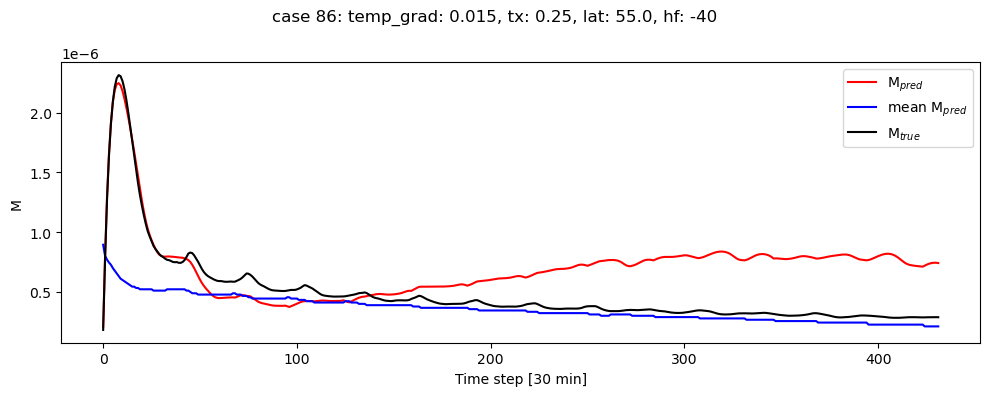

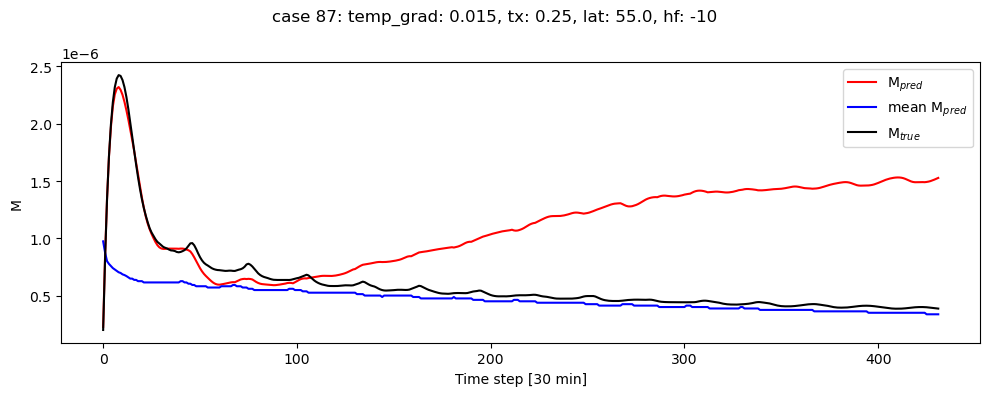

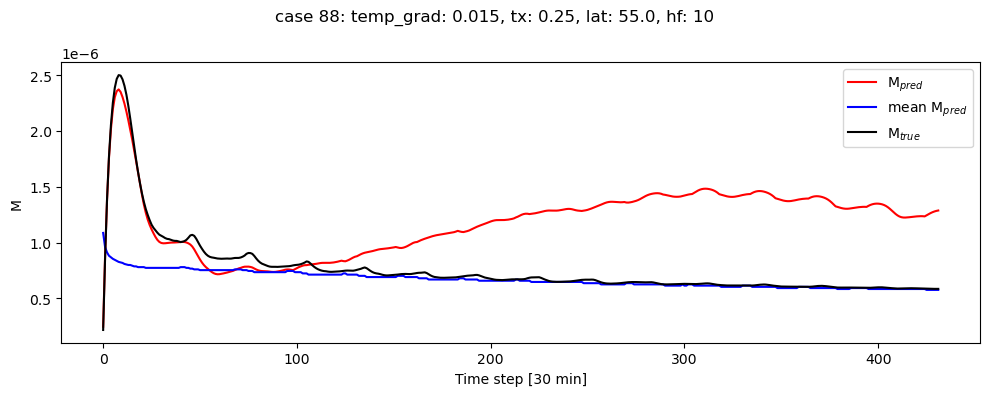

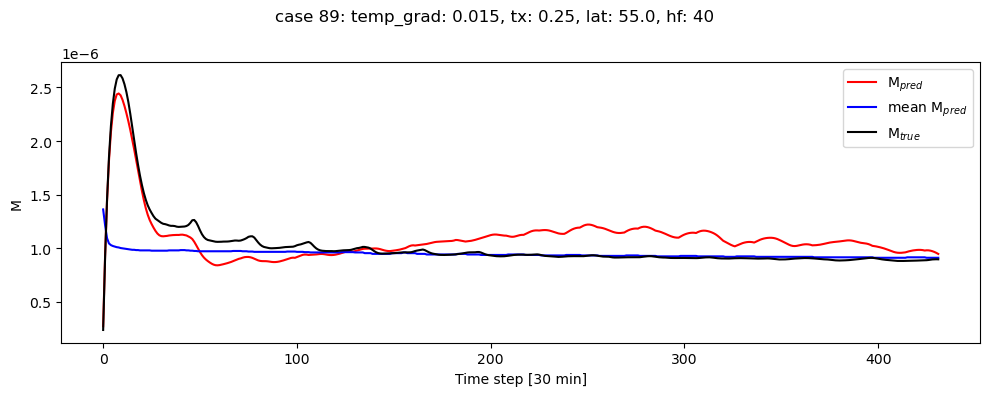

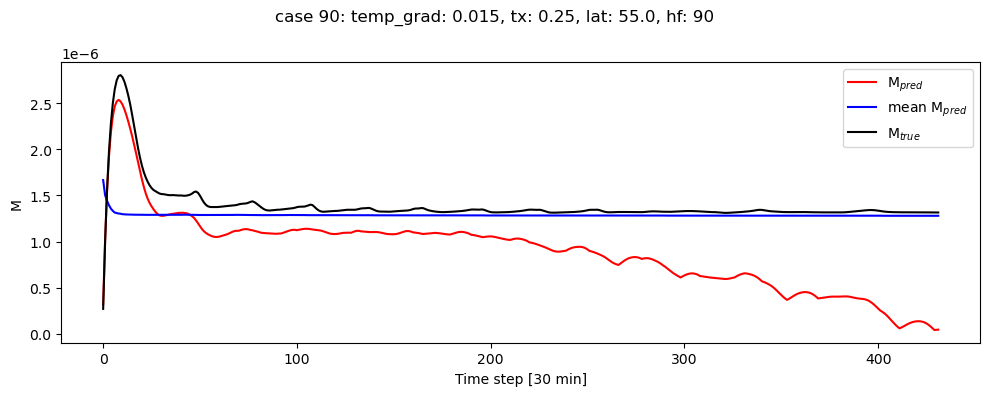

In [25]:
n_timesteps_1 = 433
n_timesteps = 432

for i in range(60,90):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    fig, ax = plt.subplots(1,1,figsize=(10,4),tight_layout=True,sharex=True)
    plt.suptitle(f"case {i+1}: temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    ax.plot(prediction[n_timesteps_1*i+1:n_timesteps_1*(i+1)], label="M$_{pred}$", color="red")
    ax.plot(mean_prediction_val.detach().numpy()[n_timesteps*i:n_timesteps*(i+1)], label="mean M$_{pred}$", color="blue")
    # ax.plot(M_algebraic[n_timesteps*i:n_timesteps*(i+1)], label="algebraic M", color="green")
    ax.plot(truth[n_timesteps_1*i+1:n_timesteps_1*(i+1)], label="M$_{true}$", color="black")
    ax.set_xlabel("Time step [30 min]")
    ax.set_ylabel("M")
    ax.legend()